# ENGR 1451/2451 — Weekly Assignment 5
**10 points**

Practice loading a CSV file, selecting complete observations, calculating correlations, making scatterplots and a correlation heat map, and writing a reusable function to compare individual and grouped data.

**Due:** See Canvas.

Complete the work directly in this notebook. Show your Python code and give brief written explanations where requested.

## What to hand in

Work this assignment with the **course tutor** in the class project. Use the course tutor as your AI help for this assignment; it keeps the record for you, so you do not need to write a separate log.

At the end of each working session, type **"make my record"** in the chat. Copy the block it produces and paste it into the **Session records** cell near the bottom of this notebook.

You do not have to finish in one sitting. To continue later, start a new chat in the same project, state which assignment you are working on and where you stopped, and continue from there. Paste the new session record below the previous one.

Session records are not graded for correctness or for how much help you needed. The code and written answers must still be your own.

## Setup

LE5-2 uses the supplied **`data/penguins.csv`** file. Keep the `data` folder beside this notebook. Use the folder containing the notebook as the working directory. The other exercises retain the embedded synthetic teaching data.

Select observations by conditions, not row positions. Calculate counts and cutoffs from the data. Label scatterplot axes with units. Keep written comments brief and tied to your calculated results.

In [2]:
from pathlib import Path

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
from IPython.display import display

## LE5-1. Compare laptop measurements (3 pts)

Each row describes one laptop. `battery_Wh` is battery capacity in watt-hours, `mass_kg` is mass in kilograms, and `runtime_h` is measured battery runtime in hours. Two entries are missing.

### A. Select complete observations (1 pt)

Create `complete` by selecting the three columns in `feature_cols` and dropping rows missing **any** of them. Report the number of laptops retained and excluded, using counts calculated from the data.

In [5]:
battery_Wh = [36, 42, 45, 48, 54, 60, 63, 66,
              72, 75, 78, 84, 90, 96, np.nan, 80]
laptops = pd.DataFrame({
    "battery_Wh": battery_Wh,
    "mass_kg": [1.2, 1.1, 1.6, 1.2, 1.5, 1.3, 1.4, 1.8,
                1.5, 1.6, 1.9, 2.0, 1.7, 2.1, 1.8, 2.0],
    "runtime_h": [4.1, 6.0, 5.4, 7.6, 6.5, 8.4, 6.9, 9.8,
                  8.2, 8.0, 10.5, 9.3, 11.6, 10.0, 8.5, np.nan],
})
laptop_labels = {
    "battery_Wh": "Battery capacity (Wh)",
    "mass_kg": "Mass (kg)",
    "runtime_h": "Battery runtime (h)",
}
feature_cols = list(laptop_labels)
laptop_settings = {
    "lower_quantile": 0.25,
    "upper_quantile": 0.75,
}

# Your complete-case selection and retained/excluded counts here
complete = laptops.dropna()
retained = len(complete)
excluded = len(laptops) - retained
print(retained, "laptops were retained and ", excluded, " laptops were excluded")

14 laptops were retained and  2  laptops were excluded


### B. Plot a pair (1 pt)

Using `complete`, make a scatterplot of **battery capacity** on the x-axis and **runtime** on the y-axis. Calculate Pearson's $r$. Describe the direction and shape of the plotted association in one sentence.

**Answer:**

Correlation coefficient is 0.878
given that pearson's correlation is relatively high, as battery capacity increases, runtime increases


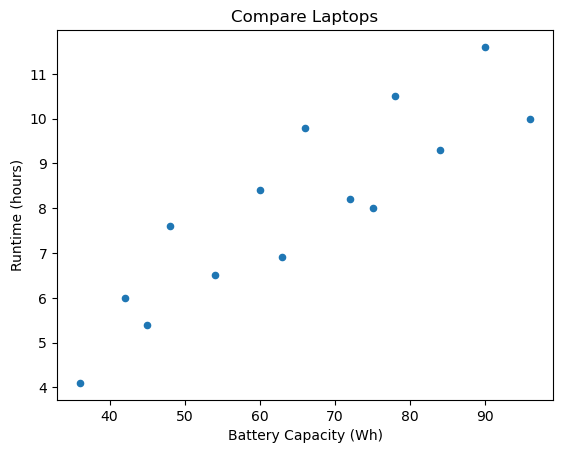

In [45]:
xcol = "battery_Wh"
ycol = "runtime_h"

# Your scatterplot and Pearson correlation here
r_laptops = complete["battery_Wh"].corr(complete["runtime_h"])
print(f"Correlation coefficient is {r_laptops:.3f}")
ax = complete.plot.scatter(x = "battery_Wh", y = "runtime_h")
ax.set(
    xlabel="Battery Capacity (Wh)",
    ylabel="Runtime (hours)",
    title="Compare Laptops"
)
plt.show
print("given that pearson's correlation is relatively high, as battery capacity increases, runtime increases")

### C. Restrict the range (1 pt)

Calculate the battery-capacity cutoffs at the quantiles specified in `laptop_settings`. Create `restricted` using `.loc[]` and `&` to keep capacities **between those cutoffs, including both endpoints**. Do not hard-code the cutoffs.

Display one table comparing the number of observations $n$ and the battery-capacity/runtime correlation $r$ for `complete` and `restricted`. Briefly report how $r$ changed.

**Answer:**

In [16]:
# Your data-derived cutoffs, Boolean filter, and n/r comparison here
lower = complete["battery_Wh"].quantile(laptop_settings["lower_quantile"])
print(upper)
upper = complete["battery_Wh"].quantile(laptop_settings["upper_quantile"])
is_within = (complete["battery_Wh"] < upper) & (complete["battery_Wh"] > lower)

restricted = complete.loc[is_within]


compare = pd.DataFrame({
    "observations (n)": [len(complete), len(restricted)],
    "r": [r_laptops, restricted["battery_Wh"].corr(restricted["runtime_h"])]
}, index = ["Complete", "Restricted"])
display(compare)

77.25


,observations (n),r
Complete,14,0.878026
Restricted,6,0.437600


## LE5-2. Cross-correlation matrix from a CSV file (3 pts)

Use the **Palmer Penguins** data in `data/penguins.csv`. Each row represents one penguin. Analyze the four physical measurements listed in `penguin_labels`; do not include species, island, sex, or year in the matrix.

Source: Horst, Hill, and Gorman, [palmerpenguins](https://allisonhorst.github.io/palmerpenguins/), with measurements collected by Kristen Gorman and Palmer Station LTER. [Variable definitions](https://allisonhorst.github.io/palmerpenguins/reference/penguins.html). The supplied CSV is the copy distributed with [plotnine](https://plotnine.org/reference/penguins.html); the data are licensed CC0. No additional package is needed to load the CSV.

### A. Load and prepare the data (1 pt)

Use `pd.read_csv()` to load `csv_path` into `penguins` and display its first few rows. Select `measurement_cols`, then drop rows missing **any of these four measurements**, storing the result as `penguin_complete`. Do not drop observations just because sex or another unused column is missing.

Report the number of rows loaded, retained, and excluded. Use the same `penguin_complete` observations throughout this exercise.

In [75]:
csv_path = Path("data/penguins.csv")
penguin_labels = {
    "bill_length_mm": "Bill length (mm)",
    "bill_depth_mm": "Bill depth (mm)",
    "flipper_length_mm": "Flipper length (mm)",
    "body_mass_g": "Body mass (g)",
}
measurement_cols = list(penguin_labels)

# Your pd.read_csv(), preview, complete-case selection, and counts here
penguins = pd.read_csv(csv_path)
#print(penguins.head())

penguin_exclude = penguins.dropna(subset = ["species","island","bill_length_mm","bill_depth_mm"])
penguin_complete = penguin_exclude[measurement_cols]
#print(penguin_complete.head())


penguins_compare_complete = pd.DataFrame({
    "observations (n)": [len(penguins), len(penguin_complete)]
}, index = ["Original", "Complete"])
display(penguins_compare_complete)

,observations (n)
Original,344
Complete,342


### B. Calculate and display the matrix (1 pt)

Calculate the **Pearson cross-correlation matrix** for all four columns of `penguin_complete` and name it `corr_matrix`. Here, the matrix contains the pairwise correlations between the measurement columns, not correlations at time lags. Display it rounded to three decimal places, keeping the unrounded matrix for plotting and subsequent calculations.

**The heat-map code is provided below; do not rewrite it.** Run the function-definition cell, then use `ax = plot_correlation_heatmap(corr_matrix)` after calculating your matrix. The fixed scale maps **−1 to dark red, 0 to white, and +1 to dark blue**.

In [27]:
# Provided plotting code: run this cell unchanged.
def plot_correlation_heatmap(corr_matrix):
    """Plot the student's matrix on a fixed red–white–blue scale."""
    cmap = LinearSegmentedColormap.from_list(
        "correlation_rwb", ["darkred", "white", "darkblue"], N=257
    )  # An odd palette size makes the middle color exactly white.

    fig, ax = plt.subplots(figsize=(7, 6))
    image = ax.imshow(
        corr_matrix, cmap=cmap, vmin=-1, vmax=1, interpolation="nearest"
    )
    positions = np.arange(len(corr_matrix.columns))
    labels = [penguin_labels[column] for column in corr_matrix.columns]
    ax.set_xticks(positions, labels=labels, rotation=45, ha="right")
    ax.set_yticks(positions, labels=labels)
    ax.set_title("Palmer Penguins: Pearson correlation matrix", pad=14)

    for (row, col), value in np.ndenumerate(corr_matrix.to_numpy()):
        ax.text(
            col, row, f"{value:.2f}", ha="center", va="center",
            color="white" if abs(value) > 0.5 else "black",
        )

    fig.colorbar(image, ax=ax, label="Pearson r", ticks=[-1, -0.5, 0, 0.5, 1])
    fig.tight_layout()
    plt.show()
    return ax

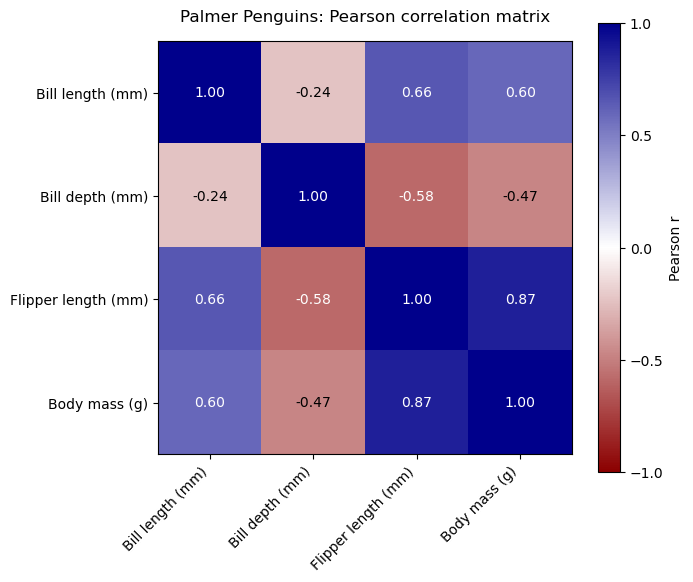

In [33]:
# Your corr_matrix calculation and rounded display here
corr_matrix = penguin_complete.corr(method="pearson")
# After calculating corr_matrix, uncomment the following line:
ax = plot_correlation_heatmap(corr_matrix)

### C. Select pairs and make a scatterplot (1 pt)

Use your matrix to identify the **strongest positive** and **strongest negative** correlations between distinct measurements. Ignore the diagonal and count each pair only once. Report both pairs and retrieve their correlations with `.loc[]`, rather than typing the correlation values by hand.

Make a scatterplot for whichever of these two pairs has the larger absolute correlation. Label the axes using `penguin_labels` and include its $r$ in the title.

0.8712017673060111
flipper_length_mm  body_mass_g          0.871202
body_mass_g        flipper_length_mm    0.871202
dtype: float64
bill_depth_mm      flipper_length_mm   -0.583851
flipper_length_mm  bill_depth_mm       -0.583851
dtype: float64


<function matplotlib.pyplot.show(close=None, block=None)>

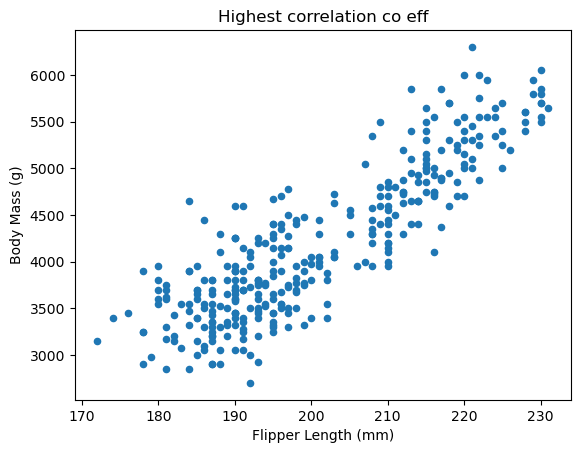

In [89]:
# Identify the two pairs and retrieve their r values from corr_matrix.
#print(corr_matrix)
corr_matrix_exclude_diagonal = corr_matrix[corr_matrix != 1]
maximum_pair = corr_matrix_exclude_diagonal.max().max()
print(maximum_pair)
a = corr_matrix[corr_matrix == maximum_pair].stack()
print(a)
max_pair_id = a.iloc[0]
minimum_pair = corr_matrix_exclude_diagonal.min().min()
b = corr_matrix[corr_matrix == minimum_pair].stack()
min_pair_id = b.iloc[0]
print(b)
# Plot the pair with the larger absolute correlation.
ax = penguin_complete.plot.scatter(x = "flipper_length_mm", y = "body_mass_g")
ax.set(
    xlabel="Flipper Length (mm)",
    ylabel="Body Mass (g)",
    title="Highest correlation co eff"
)
plt.show

## LE5-3. Compare a curved pattern with an added observation (2 pts)

A process-development team records product yield at several temperatures. Each row is one run. `yield_pct` is the percentage of starting material recovered as the desired product.

### A. Plot the original runs (1 pt)

Plot temperature on the x-axis and yield on the y-axis, then calculate Pearson's $r$. Use a condition on `yield_pct` to display the run or runs with the highest observed yield. Briefly describe the plotted pattern.

**Answer:**

Correlation coefficient is 0.008
This data should not be fitted linearly because the points follow around a distict curve.Yield increases and reaches a maximum at 50 C and then decreases


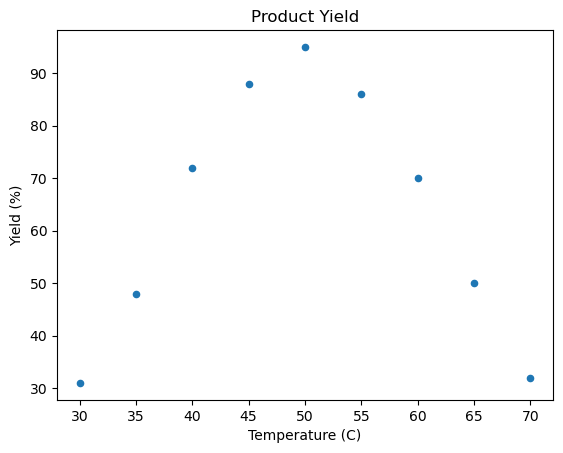

In [50]:
runs = pd.DataFrame({
    "temperature_C": [30, 35, 40, 45, 50, 55, 60, 65, 70],
    "yield_pct": [31, 48, 72, 88, 95, 86, 70, 50, 32],
})

# Your scatterplot, Pearson correlation, and maximum-yield run selection here
r_yield = runs["temperature_C"].corr(runs["yield_pct"])
print(f"Correlation coefficient is {r_yield:.3f}")
ax = runs.plot.scatter(x = "temperature_C", y = "yield_pct")
ax.set(
    xlabel="Temperature (C)",
    ylabel="Yield (%)",
    title="Product Yield"
)
plt.show
print(
    "This data should not be fitted linearly because the points follow around a distict curve."
    "Yield increases and reaches a maximum at 50 C and then decreases")

### B. Add one unusual observation (1 pt)

Use `pd.concat()` to combine `runs` and `extra_run` into a new DataFrame, `all_runs`; retain the original data.

Display one table comparing $n$ and $r$ for the original and combined data. Make a scatterplot of the combined data, marking the additional run with a different marker and adding a legend. Report the numerical change in $r$ (combined minus original).

In [56]:
extra_run = pd.DataFrame({"temperature_C": [130], "yield_pct": [5]})

# Your combined data, n/r comparison, and scatterplot here
all_runs = pd.concat([runs, extra_run])

r_runs = runs["temperature_C"].corr(runs["yield_pct"])
r_all_runs = all_runs["temperature_C"].corr(all_runs["yield_pct"])

runs_compare = pd.DataFrame({
    "observations (n)": [len(runs), len(all_runs)],
    "correlation (r)": [r_runs, r_all_runs]
}, index = ["Runs", "Combined Runs"])
display(runs_compare)

print(f"Change in r is {r_all_runs - r_runs:.3f}")



,observations (n),correlation (r)
Runs,9,0.007545
Combined Runs,10,-0.558668


Change in r is -0.566


## LE5-4. Write a function and use it twice (2 pts)

Each row below is one trainee in one of four workshops. The records give practice hours and an assembly assessment score on a 0–100 scale. These are synthetic observational records.

### A. Write and call your function (1 pt)

The individual and workshop-average analyses require the same scatterplot, count, and correlation. Write **`plot_and_summarize(data, title)`** to do that work once in a reusable function.

Your function must:

1. Create and display a **new scatterplot** of `practice_hours` on the x-axis and `assembly_score` on the y-axis. Label the axes **Practice hours (h)** and **Assembly score (0–100)**, and use the supplied `title`.
2. Calculate the number of rows $n$ and Pearson's $r$ from the supplied `data`.
3. **Return a `pd.Series`** with entries named `"n"` and `"r"`, rather than only printing them.

Use the `data` argument for every calculation and plot; do not refer to `trainees` or `workshop_means` inside the function. Do not hard-code the row count or correlation.

**First call:** Call your function on `trainees` with the title `"Individual trainees"`. Store its returned Series as `individual_summary` and display it. Write both the function body and the call yourself.

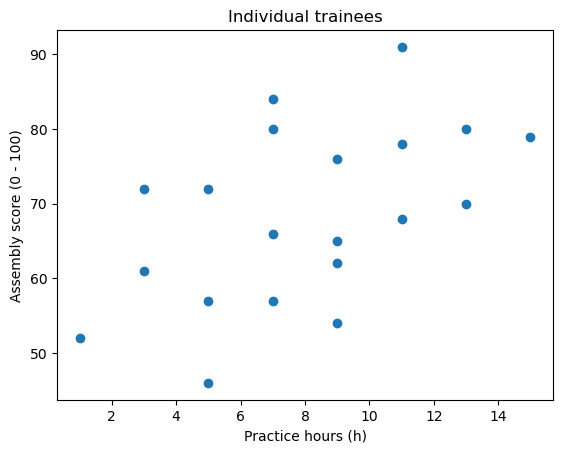

,observations (n),correlation (r)
Individual trainees,20,0.516575


In [98]:
trainees = pd.DataFrame({
    "workshop": ["A"] * 5 + ["B"] * 5 + ["C"] * 5 + ["D"] * 5,
    "practice_hours": [1, 3, 5, 7, 9, 3, 5, 7, 9, 11,
                       5, 7, 9, 11, 13, 7, 9, 11, 13, 15],
    "assembly_score": [52, 61, 46, 57, 54, 72, 57, 66, 62, 68,
                       72, 80, 65, 78, 70, 84, 76, 91, 80, 79],
})

def plot_and_summarize(data, title):
    """Plot practice hours versus score and return a Series containing n and r."""
    # Write your function body here.
    x = data.iloc[:,1]
    y = data.iloc[:,2]
    r = x.corr(y)

    series = pd.DataFrame({
        "observations (n)": len(data),
        "correlation (r)": r   
    }, index = [title])
            
    plt.scatter(x, y)
    plt.title(title)
    plt.xlabel("Practice hours (h)")
    plt.ylabel("Assembly score (0 - 100)")
    plt.show() 
    return(series)
#print(trainees)

# First call: analyze trainees and store the result as individual_summary.
individual_summary = plot_and_summarize(trainees, "Individual trainees")
# Display the returned Series.
display(individual_summary)

### B. Reuse the function for workshop averages (1 pt)

Use `.groupby(...).agg(...)` to create `workshop_means`, with one row per workshop showing its trainee count, mean practice hours, and mean assembly score. Name the count column `trainee_count`, and keep the two mean columns named **`practice_hours`** and **`assembly_score`** so the same function can analyze them. Display this table.

**Second call:** Call the **same function** on `workshop_means` with the title `"Workshop averages"`. Store its returned Series as `workshop_summary`. The returned $n$ now counts workshop rows, not individual trainees.

Use `individual_summary` and `workshop_summary` to create one labeled comparison table containing $n$ and $r$. Do not duplicate the scatterplot or correlation code outside the function. Briefly report how $r$ changed after aggregation.

**Answer:**

,practice_hours,assembly_score,trainee_count
workshop,,,
A,5.0,54.0,5
B,7.0,65.0,5
C,9.0,73.0,5
D,11.0,82.0,5


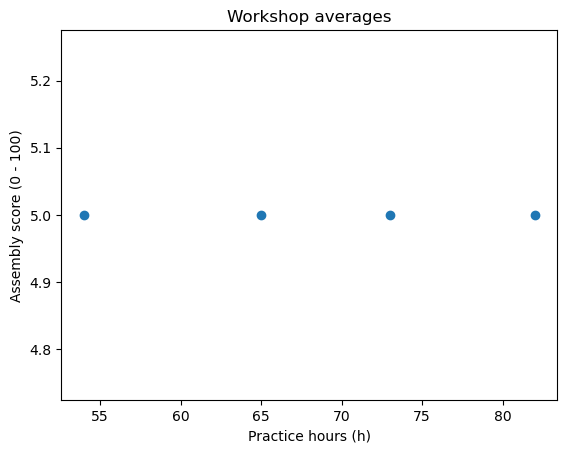

,observations (n),correlation (r)
Individual trainees,20,0.516575
Workshop averages,4,NaN


In [99]:
# Create and display workshop_means using .groupby(...).agg(...).
# Keep the mean-column names practice_hours and assembly_score.
workshop_means = trainees.groupby(["workshop"]).agg(
    
    practice_hours = ('practice_hours', 'mean'),
    assembly_score = ('assembly_score', 'mean'),
    trainee_count=('workshop', 'count')
)
display(workshop_means)
# Second call: analyze workshop_means and store the result as workshop_summary.
workshop_summary = plot_and_summarize(workshop_means, "Workshop averages")
# Combine the two returned Series into a labeled n/r comparison table.
pd.concat([individual_summary,workshop_summary])

## Session records

At the end of each working session, type **"make my record"** in the chat and paste the block it produces into the cell below. If you work across several sessions, paste each new block underneath the previous one.

<!-- Paste your session record blocks in this cell, one after another. -->

*(session records go here)*
{
  "schema_version": "engr-tutor-export-2",
  "assignment": "WA5",
  "export_n": 1,
  "session_date": "2026-10-06",
  "messages": [
    {"i": 1, "who": "student", "text": "I'm struggling with question 2. c here is what I have so far: # Identify the two pairs and retrieve their r values from corr_matrix.\n#print(corr_matrix)\ncorr_matrix_exclude_diagonal = corr_matrix[corr_matrix != 1]\nmaximum_pair = corr_matrix_exclude_diagonal.idxmax()\nprint(maximum_pair)\nminimum_pair = corr_matrix_exclude_diagonal.idxmin()\ncorr_matrix.loc[maximum_pair]\n# Plot the pair with the larger absolute correlation.", "code": true},
    {"i": 2, "who": "tutor", "text": "Masking the diagonal with `!= 1` is a good instinct, and it works without changing `corr_matrix` itself. The trouble starts at `.idxmax()`.\n\n**What `.idxmax()` does on a DataFrame.** It works column by column and returns, for each column, the row label where that column's maximum sits. The result is a Series with one entry per column, not a single pair. Here is a made-up example:\n\n```python\nimport pandas as pd\nimport numpy as np\n\nm = pd.DataFrame(\n    {\"p\": [np.nan, 0.2, -0.7],\n     \"q\": [0.2, np.nan, 0.5],\n     \"r\": [-0.7, 0.5, np.nan]},\n    index=[\"p\", \"q\", \"r\"],\n)\nm.idxmax()\n# p    q\n# q    r\n# r    q\n# (for each column, the row label of that column's largest value)\n```\n\nSo your `maximum_pair` holds several labels, one per column. It does not name the overall strongest pair. It also gets passed to `.loc[]` as if it were a single row label, which returns a block of rows rather than one correlation. And `minimum_pair` is computed but never shown or used.\n\n**Two things to keep in mind:**\n\n1. **You want one overall winner, not one per column.** One technique is `.stack()`, which flattens a matrix into a Series indexed by (row label, column label) pairs. On a Series, `.idxmax()` returns the single label of the largest value, here a (row, column) tuple. `.stack()` also drops NaN cells by default, which fits your masked frame. In my toy example, `m.stack().idxmax()` returns `(\"q\", \"r\")`. Reading the pairs off the displayed matrix, as your commented-out `print` hints, is also fine.\n2. **A symmetric matrix lists every pair twice.** The pair (q, r) and the pair (r, q) are the same correlation. That's harmless for finding the winner, but be aware of it when you report the pairs.\n\n**Retrieving a value.** Once you have two labels, `m.loc[\"q\", \"r\"]` returns the single number at that row and column. With a tuple in hand, you can pass its two parts to `.loc[]`.\n\nAlso keep in mind that \"strongest negative\" means the most negative value, not the negative value nearest zero. `.idxmin()` on the right object gives you that.\n\nSo the next step is to get a single (row, column) answer for each of your two pairs. What do you think `.stack()` would give you on your masked matrix, and does that fit what you need?"},
    {"i": 3, "who": "student", "text": "the other way I wanted to go about it was using .max() and .min() and looking for those values in the dataframe"},
    {"i": 4, "who": "tutor", "text": "That works, and it is a nice fit for what you already built: your masked frame skips the diagonal, and `.max()` and `.min()` skip NaN cells by default, so they won't be fooled by it.\n\n**Getting one overall value.** On a DataFrame, `.max()` returns one maximum per column, a Series. To get a single number you take the maximum of that Series, so `.max().max()`. The same goes for `.min().min()`. On a made-up matrix:\n\n```python\nm = pd.DataFrame(\n    {\"p\": [np.nan, 0.2, -0.7],\n     \"q\": [0.2, np.nan, 0.5],\n     \"r\": [-0.7, 0.5, np.nan]},\n    index=[\"p\", \"q\", \"r\"],\n)\ntop = m.max().max()      # 0.5, a plain number\n```\n\n**Looking for that value in the frame.** A comparison like `m == top` gives a True/False frame of the same shape. Putting it back inside `m[...]` keeps the matching cells and turns everything else into NaN. Then `.stack()` drops the NaNs and leaves a Series indexed by (row label, column label):\n\n```python\nm[m == top].stack()\n# q  r    0.5\n# r  q    0.5\n```\n\nThe index of that Series tells you which pair the value belongs to. Two things to notice:\n\n- The pair shows up twice, as (q, r) and as (r, q). The matrix is symmetric, so they are the same correlation, and either order works as the two labels in `.loc[row, column]`.\n- Comparing floats with `==` is safe here because the value came from the same frame. It could go wrong if you typed the number in by hand or compared against a rounded copy, which is another reason to keep `corr_matrix` unrounded.\n\nThe same recipe with `.min().min()` finds the most negative value. That is \"strongest negative\" in the sense the prompt means, not the negative value closest to zero.\n\nOnce you have both pairs and their values from `.loc[]`, the last decision is which one gets plotted. What do you need to compare to make that choice?"},
    {"i": 5, "who": "student", "text": "I'm having trouble with the count part of question 4: # Create and display workshop_means using .groupby(...).agg(...).\n# Keep the mean-column names practice_hours and assembly_score.\nworkshop_means = trainees.groupby([\"workshop\"]).agg('trainee_count'=('workshop', 'count'))\ndisplay(workshop_means)\n# Second call: analyze workshop_means and store the result as workshop_summary.\n\n# Combine the two returned Series into a labeled n/r comparison table.", "code": true},
    {"i": 6, "who": "tutor", "text": "Good start: grouping by `workshop` and aiming for a count column named `trainee_count` is the right shape for this step.\n\nThe error comes from the left side of the pair. In named aggregation, the new column name is written as a keyword argument, like a parameter name in a function call, so it can't be in quotes. Quotes make it a string, and Python won't accept a string as a keyword. The right side is a tuple of two strings: the source column, then the function to apply.\n\n```python\n# generic shape, on made-up data\ndf.groupby(\"team\").agg(\n    new_name=(\"source_col\", \"mean\"),\n    other_name=(\"other_col\", \"sum\"),\n)\n```\n\nThree details to keep in mind:\n\n- **Each output gets its own `name=(column, function)` pair**, separated by commas. You can list as many as you like in one `.agg()`.\n- **`\"count\"` versus `\"size\"`.** `\"count\"` counts the non-missing values in the chosen column, and `\"size\"` counts the rows in each group. They agree when nothing is missing, so either is fine for a trainee count here.\n- **Reusing a source column's name as the output name is allowed.** For example, `col=(\"col\", \"mean\")` takes the mean of `col` and keeps the name `col`. That matters for your next step, since the function reads columns called `practice_hours` and `assembly_score`.\n\nRight now your `.agg()` has only the count, so the table will have no mean columns for the function to read. Once your count line runs, what other two entries does the prompt say `workshop_means` needs, and what names must they carry?"},
    {"i": 7, "who": "student", "text": "when I have this: # Create and display workshop_means using .groupby(...).agg(...).\n# Keep the mean-column names practice_hours and assembly_score.\nworkshop_means = trainees.groupby([\"workshop\"]).agg(\n    'trainee_count'=('workshop', 'count'),\n    'practice_hours' = ('practice_hours', 'mean')\n)\ndisplay(workshop_means)\n# Second call: analyze workshop_means and store the result as workshop_summary.\n\n# Combine the two returned Series into a labeled n/r comparison table.                                              the error is this:  Cell In[91], line 4\n    'trainee_count'=('workshop', 'count'),\n    ^\nSyntaxError: expression cannot contain assignment, perhaps you meant \"==\"?", "code": true},
    {"i": 8, "who": "tutor", "text": "The error is the same one, and it is still pointing at the quotes on the left side of the `=`. Python reads `'trainee_count'=(...)` as \"assign to a string,\" which is not allowed, hence the message about assignment inside an expression. The same problem will hit your second line, `'practice_hours' = (...)`.\n\nThe fix is only to take the quotes off the new column names:\n\n```python\n# generic shape, on made-up data\ndf.groupby(\"team\").agg(\n    total=(\"score\", \"sum\"),\n    score=(\"score\", \"mean\"),\n)\n```\n\nThe left side is a bare name, like a parameter in a function call (`total=`, `score=`). The right side stays as a tuple of two quoted strings: the source column, then the function.\n\nYour two lines are built correctly otherwise: the tuples are in the right order, and `practice_hours` reusing its own source column's name is exactly what the prompt wants.\n\nYou have two of the three entries now. What is the third one the prompt lists for `workshop_means`, and what name must it carry?"},
    {"i": 9, "who": "student", "text": "The reported R for workshops is NaN # Create and display workshop_means using .groupby(...).agg(...).\n# Keep the mean-column names practice_hours and assembly_score.\nworkshop_means = trainees.groupby([\"workshop\"]).agg(\n    \n    practice_hours = ('practice_hours', 'mean'),\n    assembly_score = ('assembly_score', 'mean'),\n    trainee_count=('workshop', 'count')\n)\ndisplay(workshop_means)\n# Second call: analyze workshop_means and store the result as workshop_summary.\nworkshop_summary = plot_and_summarize(workshop_means, \"Workshop averages\")\n# Combine the two returned Series into a labeled n/r comparison table.\npd.concat([individual_summary,workshop_summary])", "code": true},
    {"i": 10, "who": "tutor", "text": "Your `workshop_means` aggregation is built correctly, with all three named outputs, the mean columns keeping their original names, and the count called `trainee_count`. The second call is also set up the way the prompt asks.\n\nThat makes me suspect the NaN comes from inside `plot_and_summarize`, since that is where r is calculated. I can't see that cell yet, so I don't want to guess. Could you paste the function cell, plus the output of `display(workshop_means)`?\n\nIn the meantime, these are the general reasons a correlation comes back NaN:\n\n- One of the two columns has a missing value in it, and the method used doesn't skip missing pairs (`np.corrcoef` returns `nan` in that case, while `.corr()` skips them).\n- One of the two columns is constant, so its standard deviation is 0 and r would divide by zero.\n- Fewer than two usable rows reach the calculation, for example if the function is computing r on a different object than the one it was handed.\n- The function cell was edited but not re-run, so the call is still using an older version.\n\nYour function's r calculation needs to read `data`, and the call has to be made after the function's cell has been run in its latest form.\n\nThere is one thing in your last line to look at once the NaN is sorted out. `pd.concat([individual_summary, workshop_summary])` stacks the two Series end to end into one long Series, so you get the entries `n`, `r`, `n`, `r` with nothing saying which pair belongs to which analysis. The prompt asks for one labeled comparison table. Building a DataFrame from a dictionary of Series puts each Series in its own labeled column:\n\n```python\npd.DataFrame({\"first\": s1, \"second\": s2})\n```\n\nThe dictionary keys become the column labels, and the Series' entry names become the rows.\n\nPaste the function cell when you can, and we'll find where the NaN comes from."},
    {"i": 11, "who": "student", "text": "trainees = pd.DataFrame({\n    \"workshop\": [\"A\"] * 5 + [\"B\"] * 5 + [\"C\"] * 5 + [\"D\"] * 5,\n    \"practice_hours\": [1, 3, 5, 7, 9, 3, 5, 7, 9, 11,\n                       5, 7, 9, 11, 13, 7, 9, 11, 13, 15],\n    \"assembly_score\": [52, 61, 46, 57, 54, 72, 57, 66, 62, 68,\n                       72, 80, 65, 78, 70, 84, 76, 91, 80, 79],\n})\n\ndef plot_and_summarize(data, title):\n    \"\"\"Plot practice hours versus score and return a Series containing n and r.\"\"\"\n    # Write your function body here.\n    x = data.iloc[:,1]\n    y = data.iloc[:,2]\n    r = x.corr(y)\n\n    series = pd.DataFrame({\n        \"observations (n)\": len(data),\n        \"correlation (r)\": r   \n    }, index = [title])\n            \n    plt.scatter(x, y)\n    plt.title(title)\n    plt.xlabel(\"Practice hours (h)\")\n    plt.ylabel(\"Assembly score (0 - 100)\")\n    plt.show() \n    return(series)\n#print(trainees)\n\n# First call: analyze trainees and store the result as individual_summary.\nindividual_summary = plot_and_summarize(trainees, \"Individual trainees\")\n# Display the returned Series.\ndisplay(individual_summary)", "code": true},
    {"i": 12, "who": "tutor", "text": "Thanks for pasting the function. The NaN comes from these two lines:\n\n```python\nx = data.iloc[:,1]\ny = data.iloc[:,2]\n```\n\n`.iloc[:, k]` picks a column by its position, counting from 0. In `trainees` the columns are `workshop`, `practice_hours`, `assembly_score`, so positions 1 and 2 happen to be the two you want, and the first call works. In `workshop_means` the order is different (the means come first and `trainee_count` last, and `workshop` is now the row index rather than a column), so positions 1 and 2 land on `assembly_score` and `trainee_count`. The count is the same for every workshop, so it is a constant column, its standard deviation is 0, and r comes out NaN. That is the \"constant column\" case from my list.\n\nIt also breaks the Setup cell's rule about selecting by condition or label rather than by position. Columns can be picked by name with `data[\"col_name\"]`, which keeps working however the frame is arranged. Plain column names are the right tool here because the function is meant to work on whichever frame it is given, as long as it has those two columns.\n\nTwo other things to look at, both from the prompt:\n\n- **The return type.** You build a one-row DataFrame indexed by the title and name its columns `\"observations (n)\"` and `\"correlation (r)\"`. The prompt asks for a `pd.Series` with entries named `\"n\"` and `\"r\"`. That matters for your last step, because the comparison table is built from the two returned Series. A Series made from a dictionary looks like this:\n\n```python\npd.Series({\"a\": 1, \"b\": 2.5})\n```\n\n- **A new figure per call.** `plt.scatter` with no `plt.subplots()` draws on whichever figure is current. The prompt asks for a new scatterplot each time, and creating a figure with `fig, ax = plt.subplots()` and drawing with `ax.scatter(...)` guarantees that. Methods like `ax.set_xlabel` replace `plt.xlabel`.\n\nOnce the function is fixed and its cell re-run, the two calls need re-running too. After that, the `pd.DataFrame({\"first\": s1, \"second\": s2})` pattern from my last message will give you the labeled comparison.\n\nStarting with the column selection, how would you pick `practice_hours` and `assembly_score` out of `data` by name?"}
  ],
  "events": [
    {"i": 1, "part": "5-2C", "type": "code"},
    {"i": 2, "part": "5-2C", "type": "explain"},
    {"i": 4, "part": "5-2C", "type": "explain"},
    {"i": 5, "part": "5-4B", "type": "code"},
    {"i": 6, "part": "5-4B", "type": "explain"},
    {"i": 7, "part": "5-4B", "type": "code"},
    {"i": 8, "part": "5-4B", "type": "explain"},
    {"i": 9, "part": "5-4B", "type": "code"},
    {"i": 11, "part": "5-4A", "type": "code"}
  ],
  "parts": [
    {"part": "5-2C", "exchanges": 2, "max_tier": 2, "passed": false},
    {"part": "5-4A", "exchanges": 1, "max_tier": 3, "passed": false},
    {"part": "5-4B", "exchanges": 3, "max_tier": 3, "passed": false}
  ],
  "tutor_assessment": [
    "The student stalled longest in 5-4B, first on named-aggregation syntax (quoted column names on the left of the equals sign, over two exchanges), then on a NaN workshop r that came from selecting columns by position with .iloc inside plot_and_summarize (a 5-4A issue surfacing in 5-4B). In 5-2C the sticking point was using .idxmax() on a DataFrame, which returns one label per column rather than one overall pair.",
    "No unstuck declarations or release-valve requests occurred in this session, and nothing in the tutoring looked like a failure. The 5-4A function still needs fixing (positional columns, DataFrame instead of a Series, no new figure per call) and the 5-4B comparison table is still built with pd.concat, so both steps remain open."
  ]
}

## Before you submit

1. **Restart Kernel and Run All Cells** and confirm that every cell runs without errors.
2. Confirm that all calculations, tables, and plots are visible in the saved notebook.
3. Confirm that your written answers are complete and your session record block(s) are pasted above.
4. Save the completed `.ipynb` file.
5. Submit the `.ipynb` file in Canvas.